<a href="https://colab.research.google.com/github/PioPio31/AnaliticaDeDatos_Equipo1/blob/main/Practica2_U2/Actividad2_PaolaIbarra23111420.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**INSTITUTO TECNOLOGICO DE CIUDAD JUAREZ**

**Ciencia y analítica de datos**

MODELOS DE APRENDIZAJE


**ACTIVIDAD 2**
Exploración de datos

---

*   NOMBRE: Paola Ibarra Ordaz
*   NO. CONTROL: 23111420

-------

# CODIGO PARA ACCEDER A NUESTRO DRIVE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# IMPORTA LAS LIBRERIAS NECESARIAS

In [ ]:
#libreria manipulacion de datos
import pandas as pd


#libreria para calculos numericos y estadisticos
import numpy as np


#Librerias para graficar
import matplotlib.pyplot as plt
import seaborn as sns




# CONVIERTE ARCHIVO CSV A TIPO DataFrame (df)

In [ ]:
credit_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/analitica datos/credit_risk_dataset.csv')
credit_df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


----

# **Parte 1**. Análisis descriptivo (univariante)

1. Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas cualitativas?

<font color="orange">8 son numéricas y 4 cualitativas.</FONT>

>


In [ ]:
#.info()muestra la informacion del dataframe numero de columnas y del tipo de dato de cada una de las columnas
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


 2. Determina el porcentaje de valores faltantes por columna.

In [ ]:
#.isna() revisa si existen valores nulos
#.mean() calcula promedio
(credit_df.isna().mean()*100)

,0
person_age,0.000000
person_income,0.000000
person_home_ownership,0.000000
person_emp_length,2.747000
loan_intent,0.000000
loan_grade,0.000000
loan_amnt,0.000000
loan_int_rate,9.563856
loan_status,0.000000
loan_percent_income,0.000000


----

# Análisis de variables numéricas

3. Obtén las siguientes estadísticas descriptivas para todas las variables numéricas:
*   Tendencia central (media, mediana)
*   Dispersión o variabilidad (min, max, desviación estándar, cuartiles)
*   Forma (asimetría y curtosis)
*   Clasifica las variables `person_age` y `loan_in_rate` según los valores observados de asimetría y curtosis

**NOTA**. Recuerda que muchas de estas estadísticas, puedes obtenerlas utilizando la función `describe()` y que la mediana está representada en el 2do cuartil (50%)

#

In [ ]:
numericas = credit_df[['person_age','person_income', 'person_emp_length', 'loan_amnt',
                       'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length']]
est_descriptivas = numericas.describe().T
# Añadimos la asimetría y la curtosis
est_descriptivas['asimetria'] = numericas.skew()
est_descriptivas['curtosis'] = numericas.kurtosis()

est_descriptivas

,count,mean,std,min,25%,50%,75%,max,asimetria,curtosis
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00,2.581393,18.560825
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00,32.865349,2693.272776
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00,2.614455,43.722338
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00,1.192477,1.423565
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22,0.208550,-0.671609
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00,1.364888,-0.137088
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83,1.064669,1.223687
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00,1.661790,3.716194


<font color="orange">En person_age el sesgo es positivo y la curtosis es positiva (LeptoKurtis).</FONT>
<br>
<font color="orange">En loan_int_rate el sesgo es positivo y la curtosis es negativa (PlatyKurtis).</FONT>

------

4. Utiliza histogramas para determinar la distribución de los valores representados en cada variable.
*   ¿Se corresponde con lo obtenido en el cálculo de asimetría? Como verás, los datos reales son más complejos que la teoría. Por esta razón, recuerda siempre acompañar el análisis de la asimetría con algún gráfico como un histograma.

**NOTA**. Para esto también puedes ocupar los gráficos `kde` ([kernel density estimation](https://www.cienciadedatos.net/documentos/pystats02-kernel-density-estimation-kde-python.html)) que crean una curva continua y suave expandiendo la idea del histograma.

<font color="orange">Sí, se corresponde. Los histogramas permiten visualizar de manera clara lo que indican los valores de asimetría y curtosis. Por ejemplo, en el histograma de person_age se observa una concentración de los datos principalmente entre los 20 y 30 años, mientras que aparecen algunas barras muy pequeñas y aisladas hacia la derecha, correspondientes a edades de 100 años o más, confirmando una asimetría positiva y una curtosis puntiaguda.
</FONT>

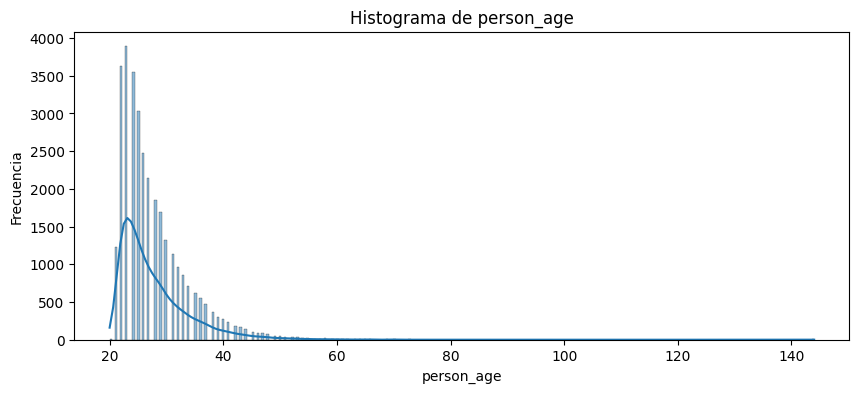

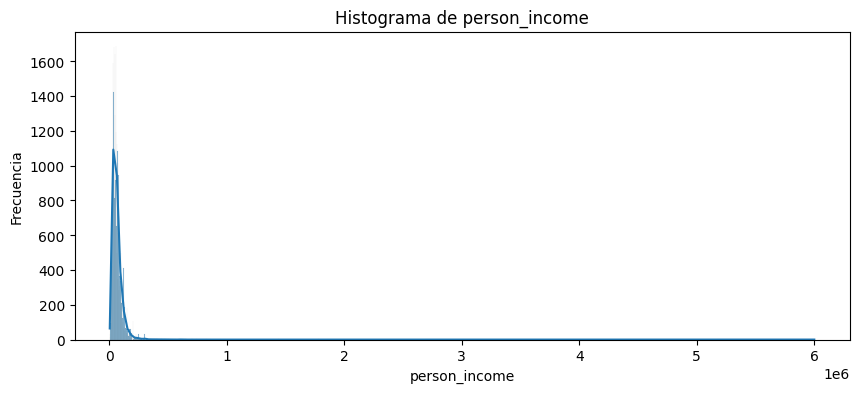

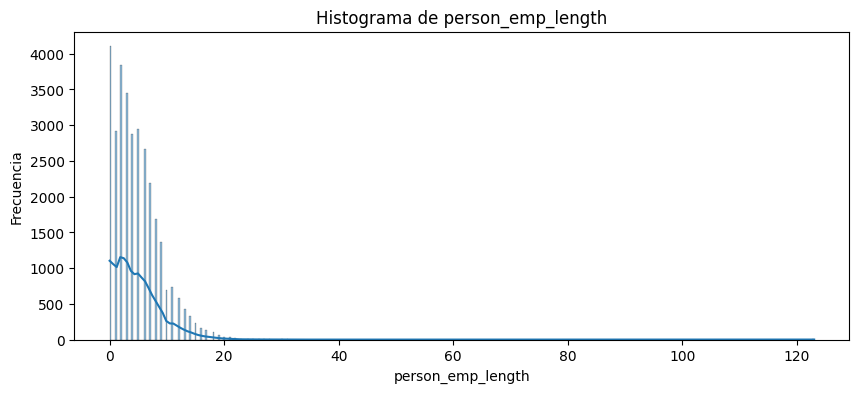

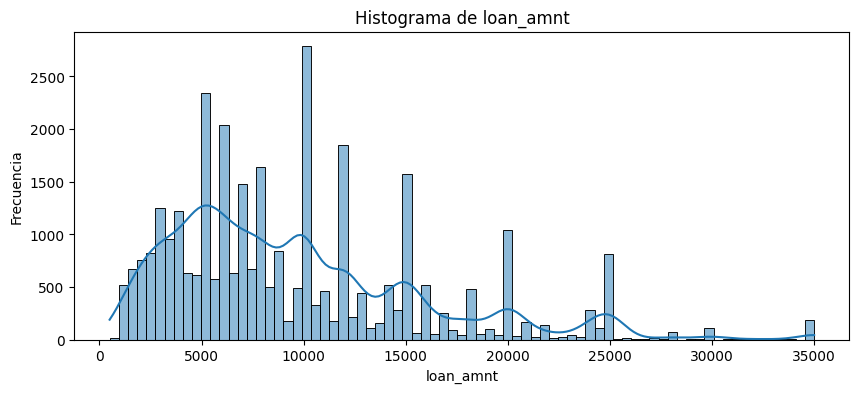

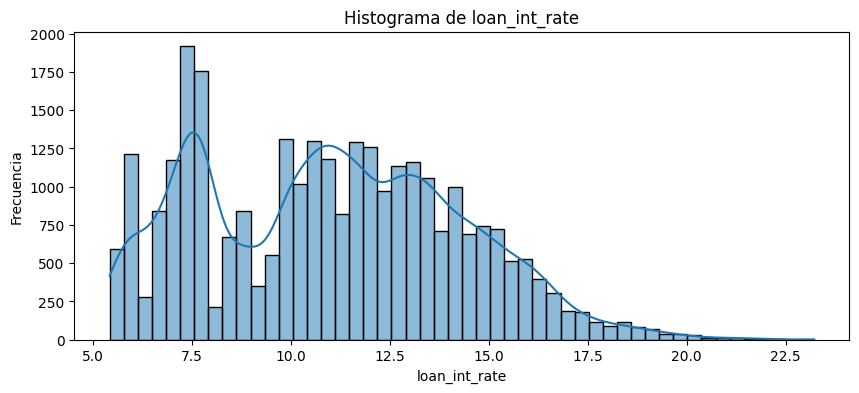

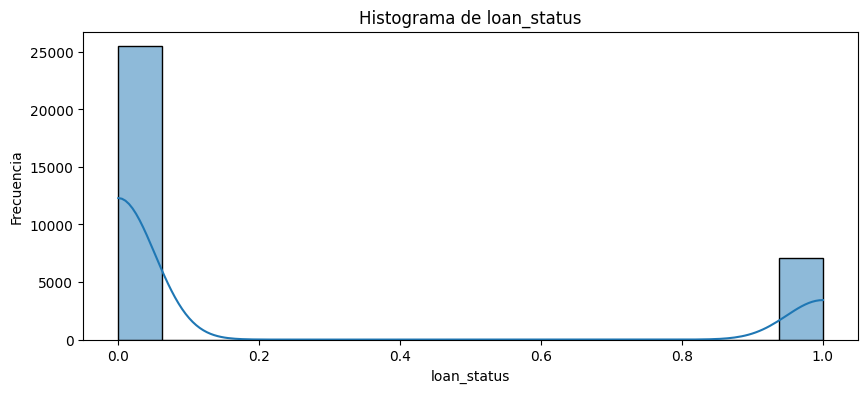

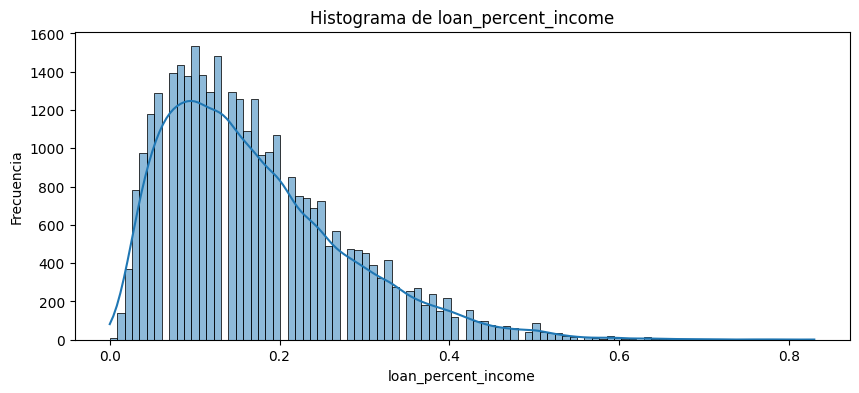

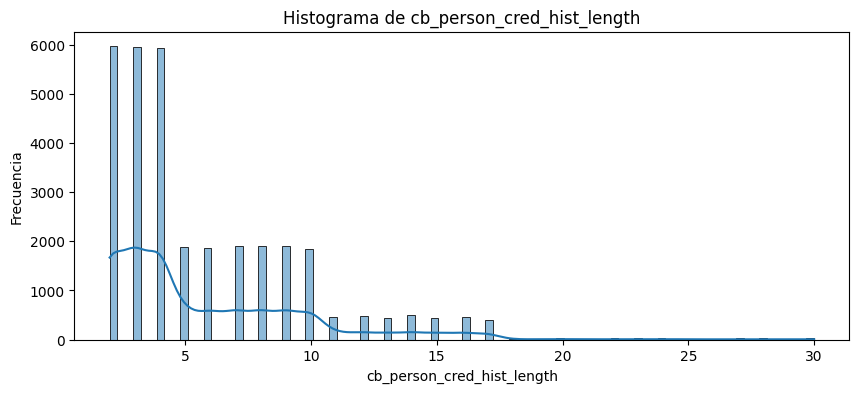

In [ ]:
#Se crean histogramas de todas las variables numéricas
for col in numericas:
  plt.figure(figsize=(10, 4))
  sns.histplot(credit_df[col], kde=True)
  plt.title(f'Histograma de {col}')
  plt.xlabel(col)
  plt.ylabel('Frecuencia')
  plt.show()

----

5. Emplea boxplots para mostrar la distribución de los datos a través de sus cuartiles.

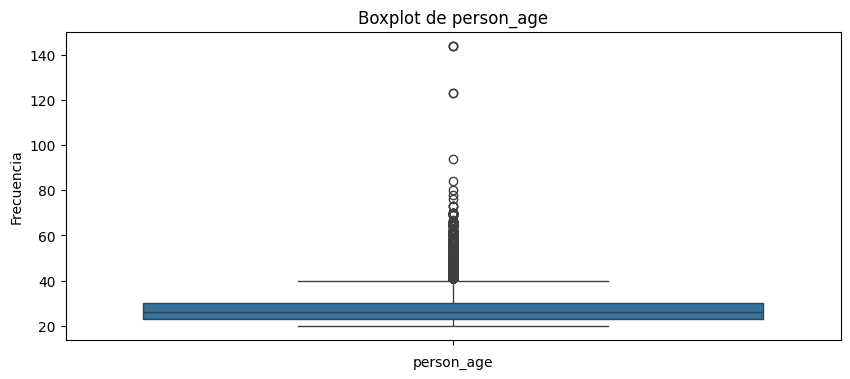

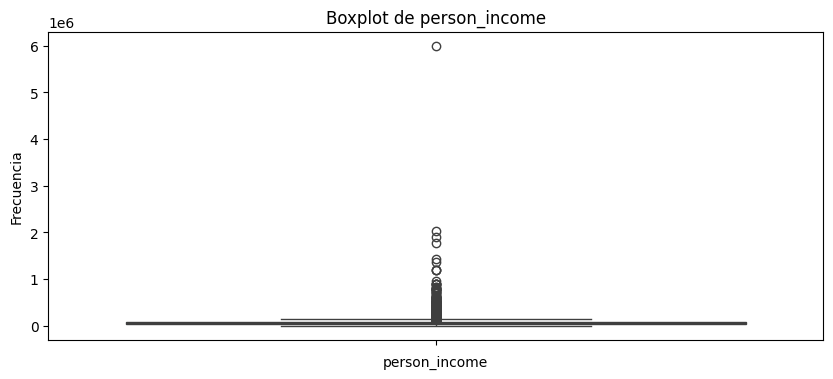

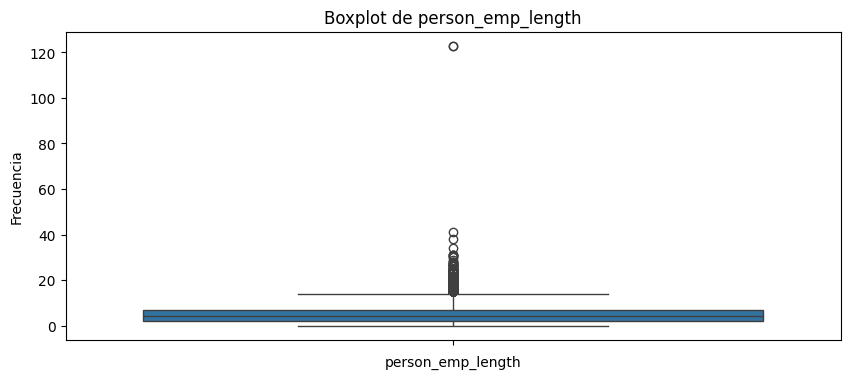

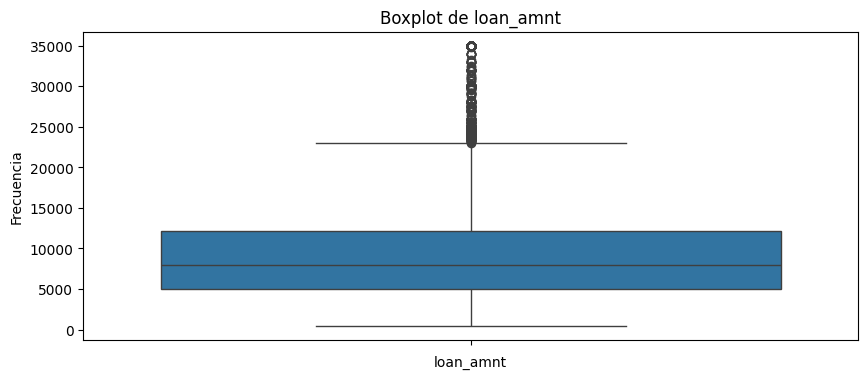

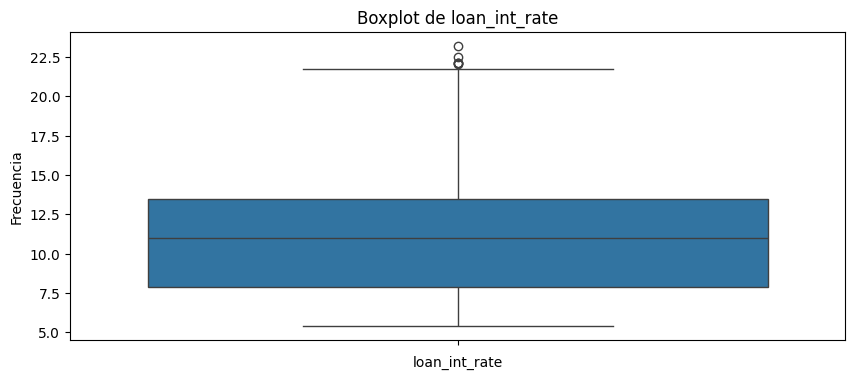

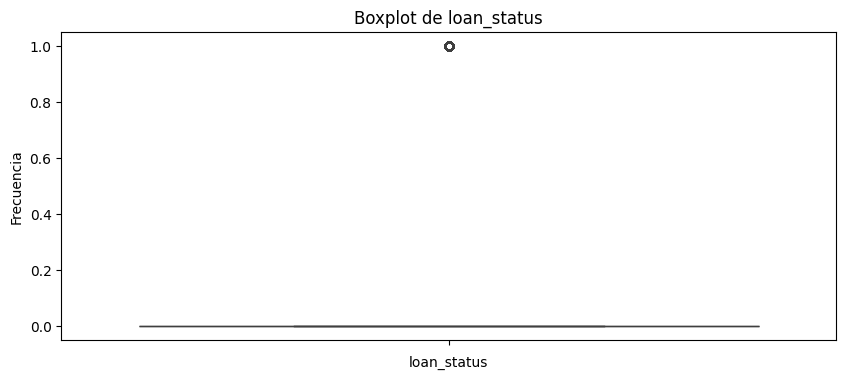

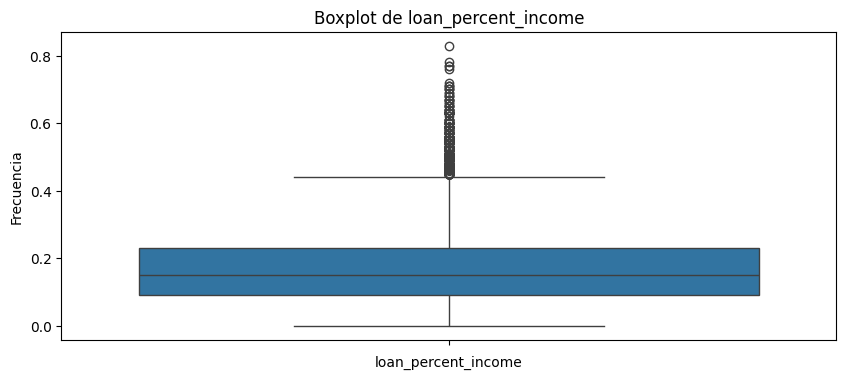

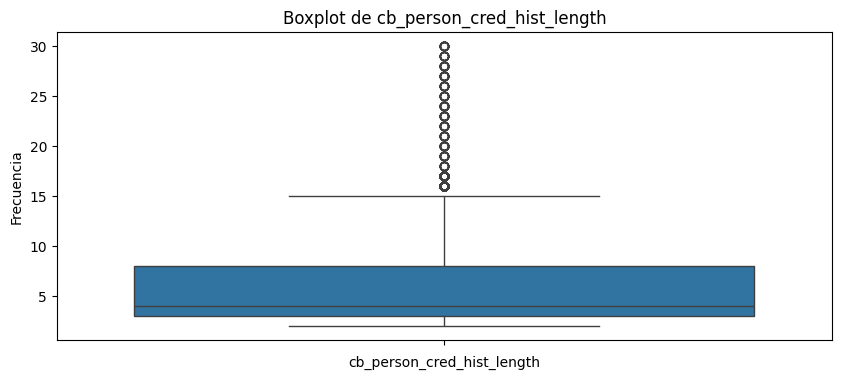

In [ ]:
#AGREGA TODAS LAS CELDAS DE CODIGO Y TEXTO QUE NECESITES
for col in numericas:
  plt.figure(figsize=(10, 4))
  sns.boxplot(credit_df[col])
  plt.title(f'Boxplot de {col}')
  plt.xlabel(col)
  plt.ylabel('Frecuencia')
  plt.show()

-----

*   Como podrás observar hay valores atípicos en todas las variables. Ejecuta el siguiente código para identificar los valores atípicos en la variable `person_age`

**Interpretación Resultados**

<FONT COLOR="ORANGE">Los resultados muestran las filas que contienen edades consideradas atípicas de acuerdo con el método del Rango Intercuartílico (IQR). Se observa que varias edades a partir de los 100 años, e incluso algunas menores, aparecen dentro de esta lista. Esto permite identificar que la alta asimetría y curtosis de person_age se relacionan principalmente con un pequeño grupo de valores extremadamente altos, que probablemente corresponden a errores en la captura de los datos, como el caso de una edad de 144 años. En un análisis real, estos valores requieren ser revisados y tratados, ya sea corrigiéndolos o eliminándolos, antes de utilizar los datos para construir un modelo.</FONT>

In [ ]:
#COMENTE CADA LINEA DE CODIGO EXPLICANDO SU USO
# Calcula el primer cuartil (percentil 25) de la columna 'person_age'
percentile_25 = credit_df["person_age"].quantile(0.25)
# Calcula el tercer cuartil (percentil 75) de la columna 'person_age'
percentile_75 = credit_df["person_age"].quantile(0.75)
# Calcula el Rango Intercuartílico (IQR), que es la diferencia entre el tercer y primer cuartil
iqr = percentile_75 - percentile_25

# Calcula el límite superior para detectar valores atípicos
# Cualquier valor por encima de este límite se considera un valor atípico
upper_limit = percentile_75 + 1.5 * iqr
# Calcula el límite inferior para detectar valores atípicos
# Cualquier valor por debajo de este límite se considera un valor atípico
lower_limit = percentile_25 - 1.5 * iqr
# Filtra el DataFrame para mostrar solo las filas donde 'person_age' está fuera de los límites
IQR_outliers = credit_df[(credit_df["person_age"] < lower_limit) | (credit_df["person_age"] > upper_limit)]
IQR_outliers # Se muestra el DataFrame resultante

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
29121,50,900000,MORTGAGE,11.0,DEBTCONSOLIDATION,B,30000,12.69,0,0.03,N,15
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


-----

# Análisis de variables de texto

 6. Obtén las siguientes estadísticas descriptivas para todas las variables de texto:
*   Tendencia central (moda)
*   Cardinalidad (cantidad de valores únicos)
*   Recuentos únicos (número de ocurrencias para cada valor único)

**NOTA**. Un resumen de estas estadísticas, puedes obtenerlas indicando en la función `describe()` que se incluirán sólo las variables de tipo object: `describe(include = 'object')`. Para los recuentos utiliza la función `df['columna'].value_counts()`

In [ ]:
#IDENTIFIQUE CUALES SON LAS VARIABLES DE TEXTO
credit_df.describe(include='object')

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


In [ ]:
categoricas = credit_df[['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']]
for col in categoricas:
  print(f'\nVariable: {col}')
  print(f'- Moda: {credit_df[col].mode()[0]}')
  print(f'- Cardinalidad: {credit_df[col].nunique()}')
  print(f'- Recuentos únicos: \n{credit_df[col].value_counts()}')


Variable: person_home_ownership
- Moda: RENT
- Cardinalidad: 4
- Recuentos únicos: 
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

Variable: loan_intent
- Moda: EDUCATION
- Cardinalidad: 6
- Recuentos únicos: 
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

Variable: loan_grade
- Moda: A
- Cardinalidad: 7
- Recuentos únicos: 
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

Variable: cb_person_default_on_file
- Moda: N
- Cardinalidad: 2
- Recuentos únicos: 
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64


-----

7. Utiliza gráficos de barras por variable para representar la frecuencia de cada categoría.

**NOTA**. seaborn posee un gráfico de recuento, para variables de tipo object, que calcula la frecuencia de cada categoría sin necesidad de utilizar la función `value_counts()`. Para generarlo debes indicar la columna: `sns.countplot(x='columna', data=df) `

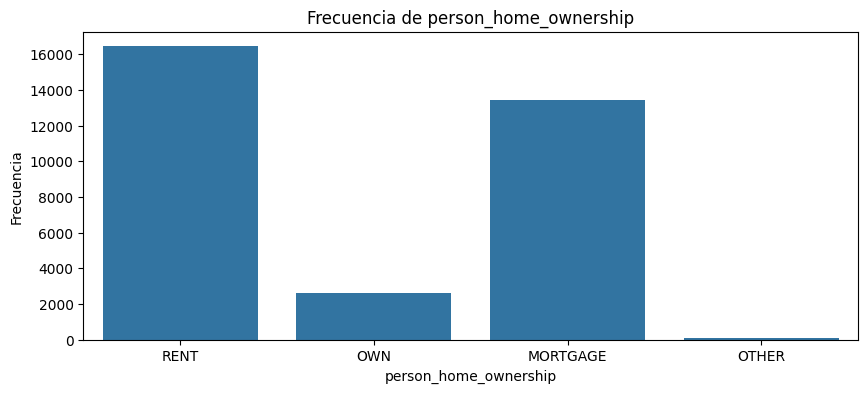

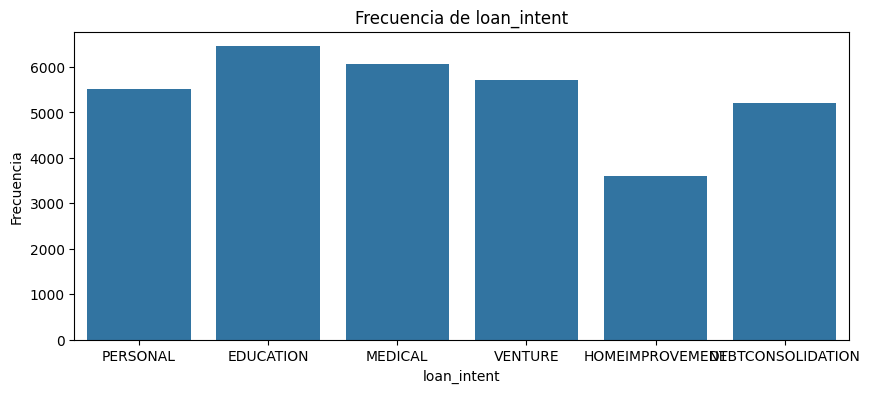

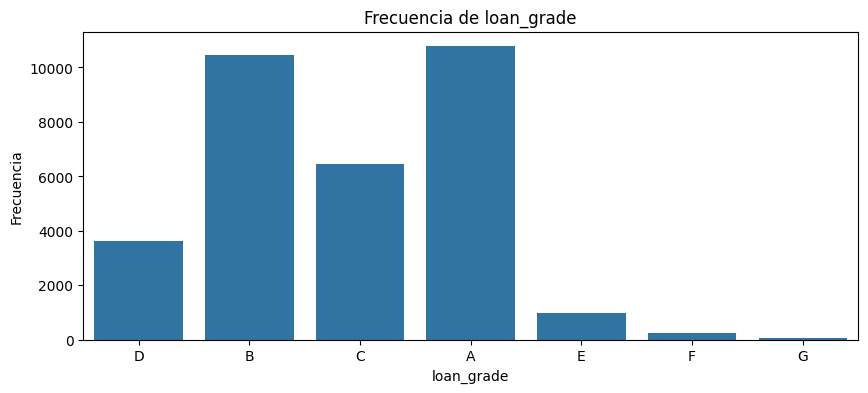

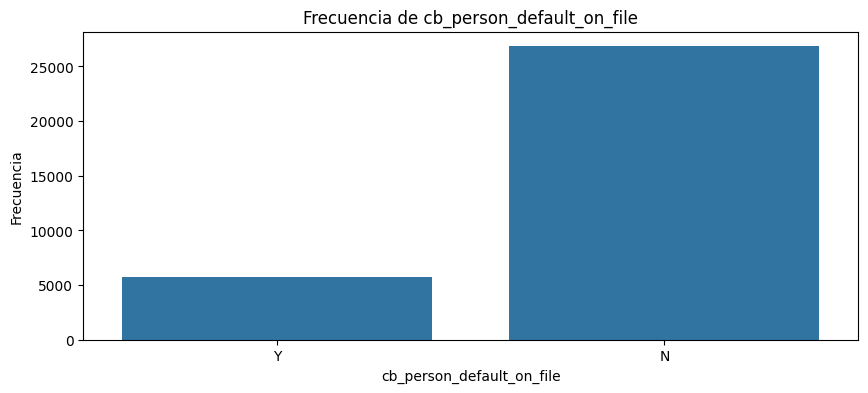

In [ ]:
#Gráfica de barras para cada variable categórica
for col in categoricas:
  plt.figure(figsize=(10, 4))
  sns.countplot(x=col, data=credit_df)
  plt.title(f'Frecuencia de {col}')
  plt.xlabel(col)
  plt.ylabel('Frecuencia')

-----

# **Parte 2**. Análisis de correlación (bivariante y multivariante)

La variable `loan_status` será la variable de salida (o a predecir en un modelo de ML). Analiza su relación con el resto de las variables a través de los siguientes gráficos:

8. Un box plot para visualizar la distribución de `loan_percent_income` según el `loan_status`. Interpreta el resultado.

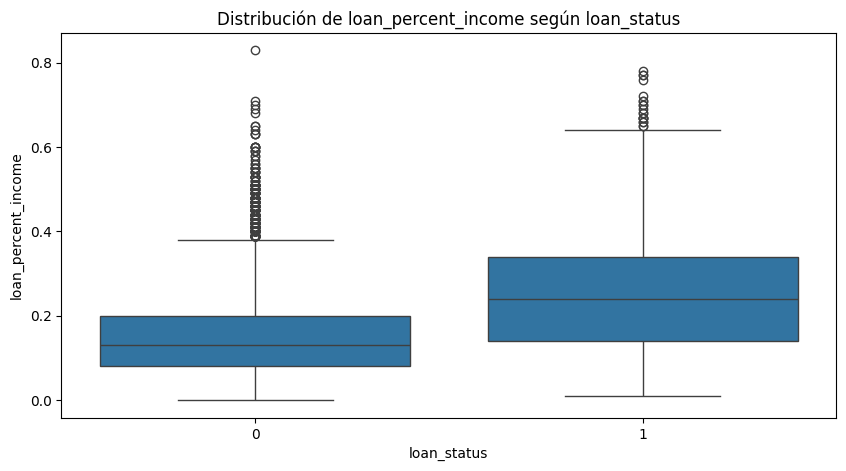

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='loan_status', y='loan_percent_income', data=credit_df)
plt.title('Distribución de loan_percent_income según loan_status')
plt.xlabel('loan_status')
plt.ylabel('loan_percent_income')
plt.show()

**Interpretación resultados**

<FONT COLOR="ORANGE">El boxplot compara loan_percent_income entre los préstamos pagados (loan_status = 0) y los que presentan impago (loan_status = 1). Se observa que los valores de los préstamos impagados tienden a ser más altos, lo que muestra una relación entre un mayor porcentaje de ingreso destinado al préstamo y una mayor presencia de impagos. Esto puede explicarse porque destinar una mayor parte del ingreso al pago del préstamo dificulta su cumplimiento.</FONT>



 9. En los gráficos de barras que obtuviste en el ejercicio 7, separa el conteo según el `load_status`, utilizando el parámetro `hue`.

In [ ]:
#AGREGUE TODAS LAS CELDAS DE CODIGO Y TEXTO QUE NECESITE

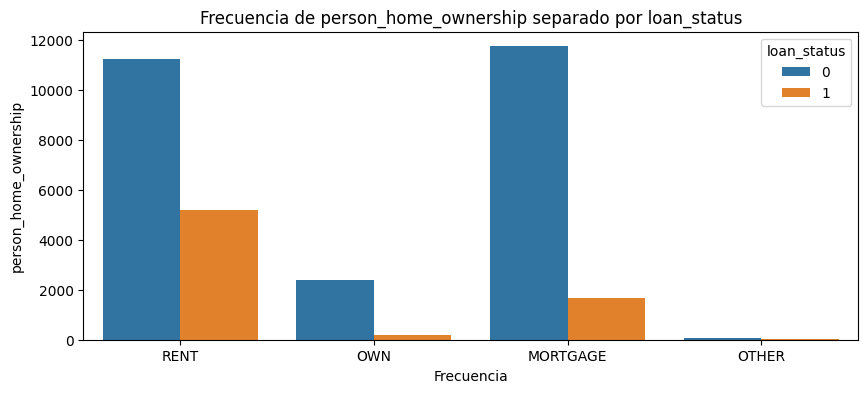

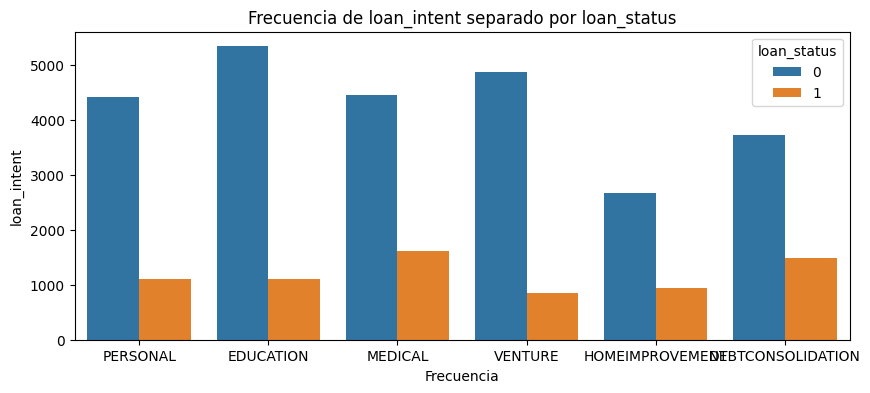

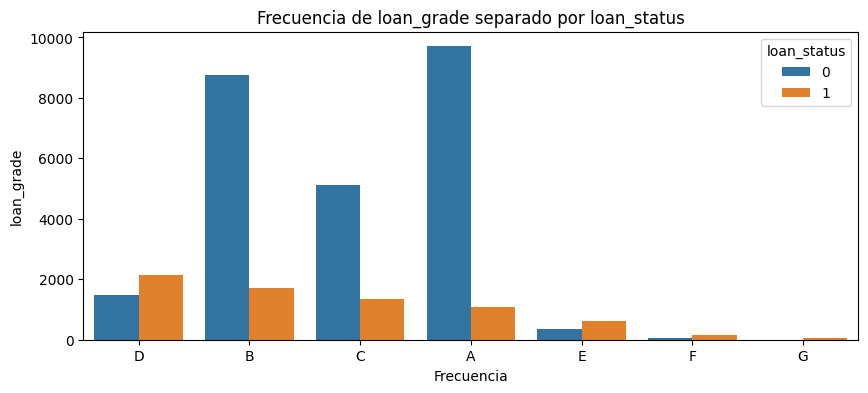

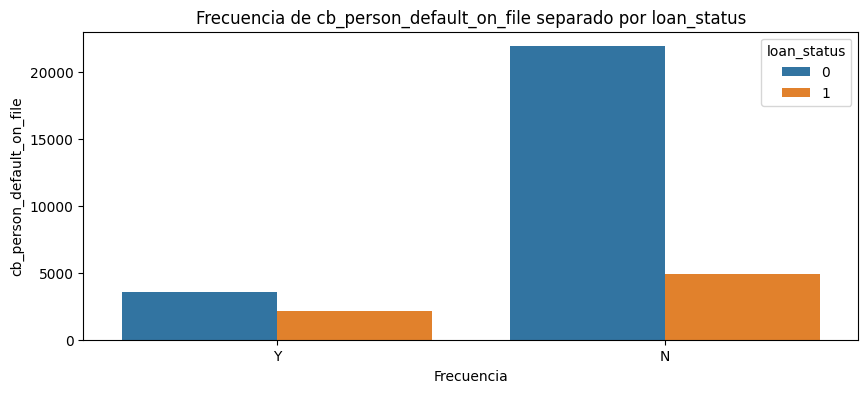

In [ ]:
for col in categoricas:
  plt.figure(figsize=(10, 4))
  sns.countplot(x=col, hue='loan_status', data=credit_df)
  plt.title(f'Frecuencia de {col} separado por loan_status')
  plt.xlabel('Frecuencia')
  plt.ylabel(col)
  plt.show()

10. Un mapa de calor con los valores de correlación de todas las variables del dataframe.
*   ¿Qué variable tiene mayor correlación con `loan_status`?

**Respuesta a pregunta**

<FONT COLOR="ORANGE">Al observar la fila de loan_status en el mapa de calor, loan_percent_income presenta la correlación positiva más alta, seguida de loan_int_rate. Esto indica que un mayor porcentaje del ingreso destinado al préstamo y una tasa de interés más alta se relacionan con una mayor presencia de impagos (loan_status = 1). También se observa una relación positiva entre person_age y cb_person_cred_hist_length, lo cual es coherente, ya que el historial crediticio tiende a ser mayor conforme aumenta la edad.</FONT>



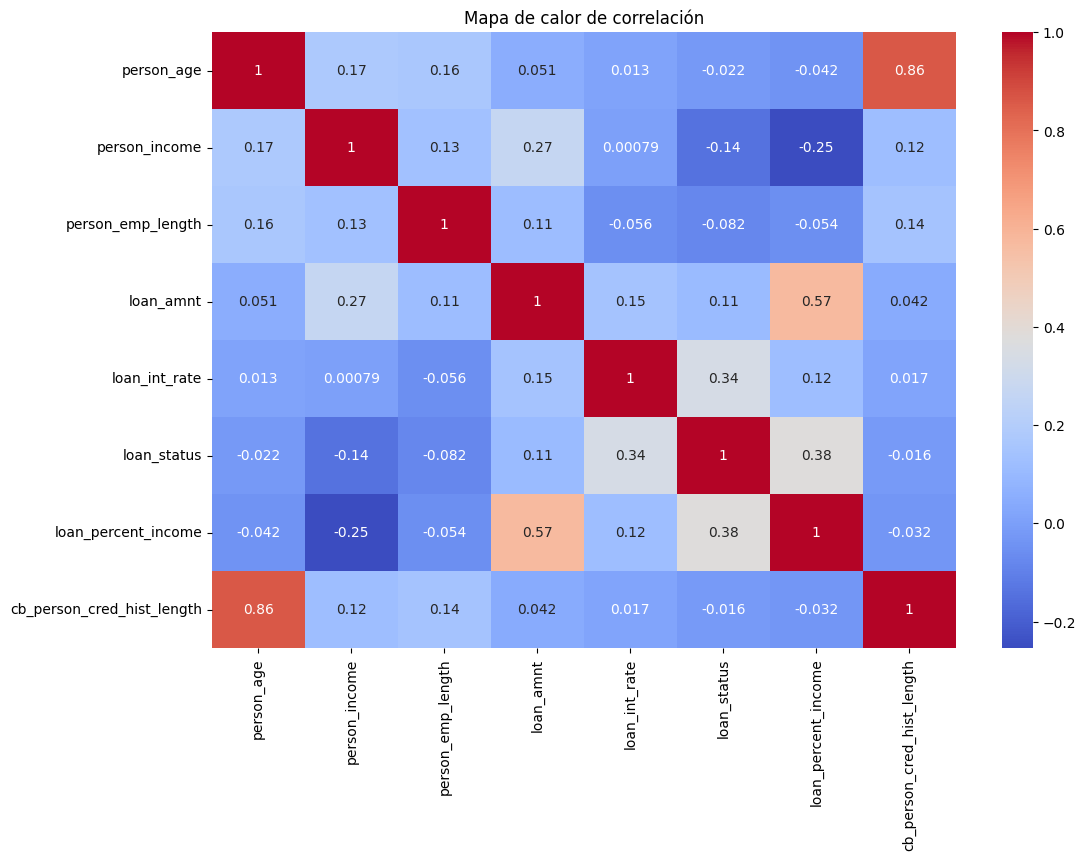

In [ ]:
#CODIGO PARA MAPA DE CALOR
plt.figure(figsize=(12, 8))
sns.heatmap(numericas.corr(), annot=True, cmap='coolwarm')
plt.title('Mapa de calor de correlación')
plt.show()